# Как работает учет позиционирования

In [1]:
# Импорты
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Параметры
max_len = 100 # длина последовательности
d_model = 20 # размерность вектора каждой позиции

## Формирование последовательности  (монотонная)
`out # torch.Size([1, 5, 4])`

In [30]:
seq = list(range(1, max_len+1))
# seq

In [32]:
input_proj = nn.Linear(1, d_model)

In [36]:
x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # [max_len, 1]
#print(x)

In [48]:
x[0, 1:10, :] #1 vector, 20 from the sequence, all d_model dimensions

tensor([[ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.]])

In [50]:
out = input_proj(x)
out.shape # [max_len, d_model]

torch.Size([1, 100, 20])

## Формирование последовательности  (не монотонная)
`out # torch.Size([1, 5, 4])`

In [53]:
seq = ['may', 'june', 'july', 'august', 'october']

In [55]:
# Словарь, отображающий слова в числа
vocab = {word: idx for idx, word in enumerate(sorted(set(seq)))}
print(vocab)  # {'august': 0, 'july': 1, 'june': 2, 'may': 3, 'october': 4}

{'august': 0, 'july': 1, 'june': 2, 'may': 3, 'october': 4}


In [59]:
# Преобразуем слова в индексы
seq_ids = [vocab[word] for word in seq]  #  ['may', 'june', 'july', 'august', 'october'] -> into -> [3, 2, 1, 0, 4]
seq_ids

[3, 2, 1, 0, 4]

In [20]:
input = nn.Linear(1, d_model)

In [61]:
# Преобразуем в тензор
x = torch.tensor(seq_ids, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # [1, 5, 1]
x

tensor([[[3.],
         [2.],
         [1.],
         [0.],
         [4.]]])

In [63]:
# Проекция
out = input_proj(x)
out.shape # [1, 5, 20]

torch.Size([1, 5, 20])

## Получение эмбеддингов позиционирования (`pos_emb`)

Yes — this snippet is part of the classic **Positional Encoding** used in Transformer models (as introduced in the *Attention is All You Need* paper). Let's break it down and write the actual mathematical formula it implements.

---

### Code Breakdown

```python
position = torch.arange(0, max_len).unsqueeze(1)  # shape: [max_len, 1]
div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))  # shape: [d_model // 2]
```

* `position`: A column vector of integers from `0` to `max_len - 1`, representing token positions in a sequence.
* `div_term`: A row vector of size `d_model // 2`, representing different frequency scales for sine and cosine waves. It's exponential in nature to allow for encoding both short- and long-range positions.

---

### The Mathematical Formula

The positional encoding at position $p$ and dimension $i$ (with $i$ from $0$ to $d_{\text{model}} - 1$) is defined as:

$$
\text{PE}(p, i) = 
\begin{cases}
\sin\left(\frac{p}{10000^{\frac{i}{d_{\text{model}}}}}\right), & \text{if } i \text{ is even} \\
\cos\left(\frac{p}{10000^{\frac{i-1}{d_{\text{model}}}}}\right), & \text{if } i \text{ is odd}
\end{cases}
$$

Or equivalently:

$$
\text{PE}_{(p,2i)} = \sin\left(p \cdot \omega_i\right), \quad \text{PE}_{(p,2i+1)} = \cos\left(p \cdot \omega_i\right)
$$

$$
\text{where } \omega_i = \frac{1}{10000^{2i / d_{\text{model}}}}
$$

---

### What Kind of Numbers Are Generated?

* The sine and cosine values are bounded in $[-1, 1]$.
* The frequencies decrease exponentially as the dimension index increases.
* For small $i$, $\omega_i$ is large → rapid oscillations (good for fine positional detail).
* For large $i$, $\omega_i$ is small → slow oscillations (good for coarse positional trends).
* The overall result is a unique encoding for each position, which allows the model to distinguish positions without relying on recurrence or convolution.

Would you like a visualization of how these encodings look across positions and dimensions?


In [71]:
def generate_sinusoidal_positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)  # чётные индексы
    pe[:, 1::2] = torch.cos(position * div_term)  # нечётные индексы
    return pe

In [73]:
pe = generate_sinusoidal_positional_encoding(max_len, d_model)
pe.shape # [max_len, d_model]

torch.Size([100, 20])

In [75]:
pos_emb = pe.unsqueeze(0)
pos_emb.shape # [1, max_len, d_model]

torch.Size([1, 100, 20])

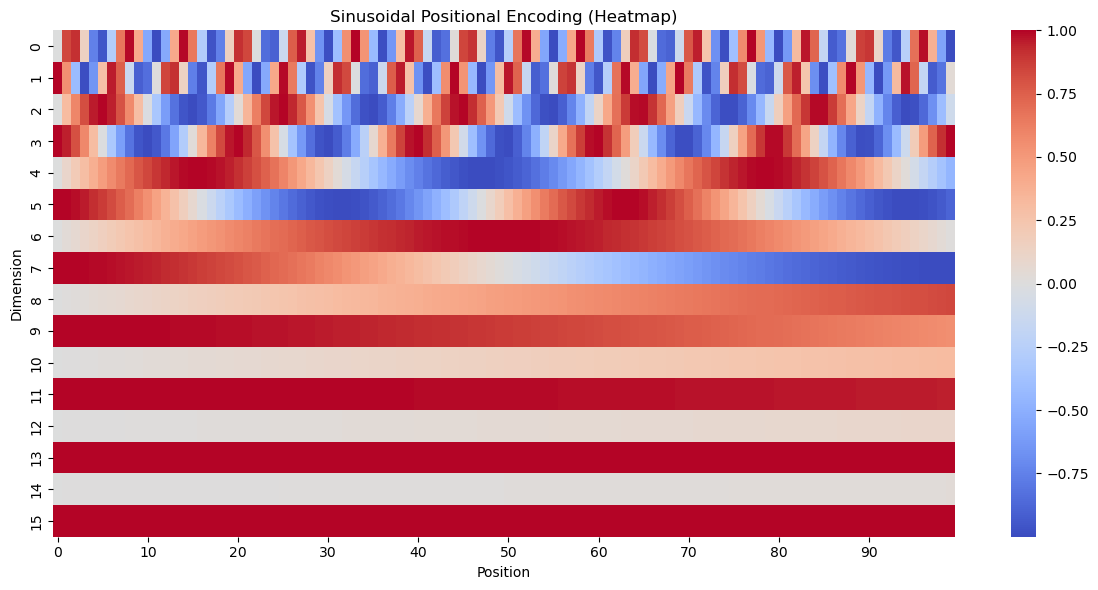

In [82]:
# visualise 
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the positional encoding
pe = generate_sinusoidal_positional_encoding(max_len=100, d_model=16)

# Plot as a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pe.T, cmap="coolwarm", xticklabels=10, yticklabels=1)
plt.title("Sinusoidal Positional Encoding (Heatmap)")
plt.xlabel("Position")
plt.ylabel("Dimension")
plt.tight_layout()
plt.show()


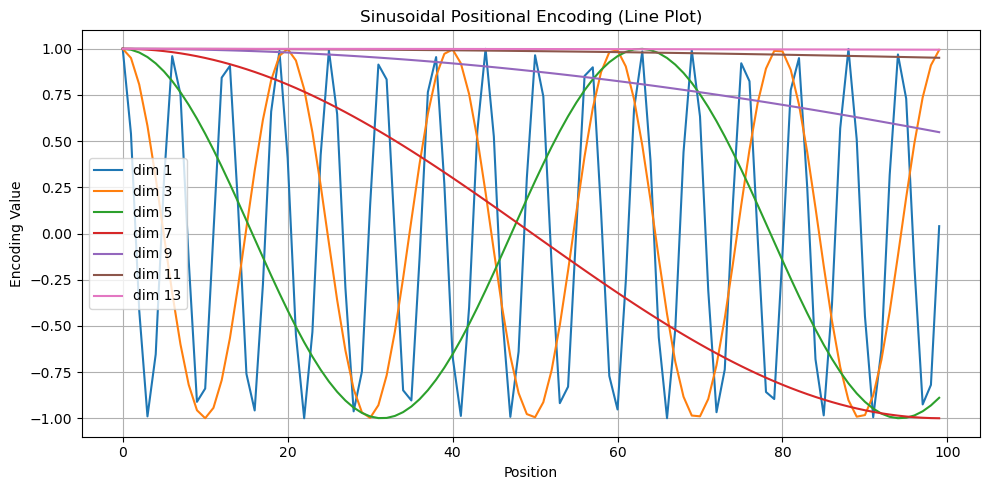

In [86]:
import matplotlib.pyplot as plt

# Generate the positional encoding
pe = generate_sinusoidal_positional_encoding(max_len=100, d_model=16)

# Plot selected dimensions
plt.figure(figsize=(10, 5))
for i in range(1, 15, 2):  # plot every 2nd dimension
    plt.plot(pe[:, i].numpy(), label=f"dim {i}")
plt.title("Sinusoidal Positional Encoding (Line Plot)")
plt.xlabel("Position")
plt.ylabel("Encoding Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


That’s a key design question — why not just use simple **position indices (0, 1, 2, ...)** or **binned values (e.g., 0–20, 21–40)** as position embeddings?

Here’s why **sinusoidal embeddings** are generally better, especially in transformer models:
---
Let’s say you use raw numbers like:
```text
pos = [0, 1, 2, 3, ..., 499]
```
or bin them like:
```text
bin_pos = [0, 0, ..., 1, 1, ..., 2, 2, ...]
```
These options have serious limitations:

| Approach                     | Problems                                                                                                                                       |
| ---------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| **Raw integers**             | Model treats them as categorical unless embedded; they have no meaningful relationship (e.g. 2 is not "twice as far" as 1 in a learnable way). |
| **Bins** (e.g., 0–20, 21–40) | Lose granularity. All positions within a bin are treated identically. Model can't distinguish between position 22 and 39.                      |
| **Learned embeddings**       | Cannot generalize to unseen positions outside training data.                                                                                   |

---
### ✅ Why Sinusoidal Positional Encodings Are Better

1. **Continuous and Smooth**

   * Every position gets a smooth, unique vector.
   * Small changes in position yield small changes in the embedding — helpful for generalization.

2. **Encodes Relative Distances**

   * Because of their sinusoidal nature, **differences between position vectors reflect relative positions**.
   * For example:

     $$
     \text{PE}(p + k) - \text{PE}(p) \approx \text{PE}(k)
     $$

     ...which makes it easier for the model to learn translation-invariant patterns (e.g., "X occurs 3 tokens after Y").

3. **Generalizes to Longer Sequences**

   * Fixed formula means you can compute embeddings for positions never seen during training (e.g., inference with longer sequences).

4. **No Extra Parameters**

   * Unlike learned position embeddings, sinusoidal encodings don’t add trainable weights. They're **parameter-free** but still expressive.

---

### 🧠 Summary

| Metric                     | Sinusoidal | Raw Numbers | Binned | Learned |
| -------------------------- | ---------- | ----------- | ------ | ------- |
| Unique per position        | ✅          | ✅           | ❌      | ✅       |
| Encodes relative distance  | ✅          | ❌           | ❌      | ❌       |
| Generalizes to longer seqs | ✅          | ✅           | ✅      | ❌       |
| Adds parameters            | ❌          | ❌           | ❌      | ✅       |
| Smooth/continuous          | ✅          | ❌           | ❌      | ✅       |

---

Let me know if you want a visual or code-based comparison (e.g. dot product similarity between different schemes)!


# ! position is still categorical (0, 1, 2...), but it’s embedded into a space where:

Similar positions → similar vectors

Regular shifts in position → predictable vector changes

This lets the model reason about order and relative distance, unlike plain categorical features.

## Результат

In [185]:
# Эмбеддинги входной последовательности с учетом позиций
x_with_pos = out + pos_emb
x_with_pos # [1, max_len, d_model]

tensor([[[ 1.8939e-01,  7.1997e-01, -8.9454e-01,  ..., -6.7241e-02,
          -2.9772e-01,  1.8032e+00],
         [ 1.6485e+00, -7.0207e-01, -1.4149e+00,  ..., -6.2657e-01,
          -2.8386e-02,  2.7830e+00],
         [ 2.3340e+00, -2.6209e+00, -1.9958e+00,  ..., -1.1859e+00,
           2.4095e-01,  3.7628e+00],
         ...,
         [ 6.0482e+01, -9.4552e+01, -8.8177e+01,  ..., -5.4324e+01,
           2.5828e+01,  9.6844e+01],
         [ 6.0147e+01, -9.5409e+01, -8.8911e+01,  ..., -5.4884e+01,
           2.6097e+01,  9.7824e+01],
         [ 6.0339e+01, -9.5512e+01, -8.9797e+01,  ..., -5.5443e+01,
           2.6367e+01,  9.8804e+01]]], grad_fn=<AddBackward0>)

Посчитаем косинусные сходства между 5 эмбеддингами без учета позиций и с учетом.

In [186]:
import torch.nn.functional as F

### Без учета позиций

In [187]:
# out: # [1, max_len, d_model] — уберем размерность батча
emb = out.squeeze(0)  # # [max_len, d_model]

# Заготовка нулевой матрицы
similarities = torch.zeros(d_model, d_model)

# Расчет косинусного сходства между всеми парами: (i, j)
for i in range(d_model):
    for j in range(d_model):
        sim = F.cosine_similarity(emb[i].unsqueeze(0), emb[j].unsqueeze(0))
        similarities[i, j] = sim

### С учетом позиций

In [188]:
# x_with_pos: [1, max_len, d_model] — уберем размерность батча
emb_pos = x_with_pos.squeeze(0)  # [max_len, d_model]

# Заготовка нулевой матрицы
similarities_pos = torch.zeros(d_model, d_model)

# Косинусное сходство между всеми парами: (i, j)
for i in range(d_model):
    for j in range(d_model):
        sim = F.cosine_similarity(emb_pos[i].unsqueeze(0), emb_pos[j].unsqueeze(0))
        similarities_pos[i, j] = sim

In [189]:
print("Косинусное сходство между позициями (без учета позиции):")
print(similarities)
print("_______________________")
print("Косинусное сходство между позициями (с учетом позиции):")
print(similarities_pos)

Косинусное сходство между позициями (без учета позиции):
tensor([[1.0000, 0.8683, 0.7743, 0.7235, 0.6926, 0.6721, 0.6574, 0.6465, 0.6380,
         0.6313, 0.6257, 0.6212, 0.6173, 0.6140, 0.6111, 0.6086, 0.6064, 0.6045,
         0.6027, 0.6012],
        [0.8683, 1.0000, 0.9862, 0.9706, 0.9592, 0.9509, 0.9446, 0.9398, 0.9359,
         0.9328, 0.9303, 0.9281, 0.9262, 0.9247, 0.9233, 0.9221, 0.9210, 0.9200,
         0.9192, 0.9184],
        [0.7743, 0.9862, 1.0000, 0.9971, 0.9927, 0.9890, 0.9859, 0.9834, 0.9813,
         0.9796, 0.9781, 0.9769, 0.9758, 0.9749, 0.9741, 0.9734, 0.9727, 0.9722,
         0.9716, 0.9712],
        [0.7235, 0.9706, 0.9971, 1.0000, 0.9990, 0.9974, 0.9958, 0.9944, 0.9932,
         0.9921, 0.9912, 0.9904, 0.9897, 0.9891, 0.9886, 0.9881, 0.9877, 0.9873,
         0.9869, 0.9866],
        [0.6926, 0.9592, 0.9927, 0.9990, 1.0000, 0.9996, 0.9989, 0.9981, 0.9973,
         0.9966, 0.9960, 0.9955, 0.9950, 0.9946, 0.9942, 0.9939, 0.9936, 0.9933,
         0.9930, 0.9928],
   

📌 Что мы получили.  
Значения в ячейках [i, j] в матрицах отражают __косинусное сходство__ (очевидно, обратная величина косинусного расстояния) между эмбеддингами токенов в позициях i и j. Чем ближе значение к 1, тем похожее поведение в модели, а если ближе к 0 или -1 — тем более они различны.   

Как видим, добавление позиционной информации корректирует эмбеддинги так, что у более близких значений величина косинусного сходства возрастает